 **TALLER DE MUESTREO, LIMITE CENTRAL Y LEY DE GRANDES NUMEROS**

$Grupo-2$

$Integrantes:$
* Juan David Gomez Mosquera
* Miguel Ayala

## **PROYECTO A REALIZAR**

* Considera una población y una variable de estudio
* Escoge un método de muestreo probabilístico.
* Toma suficientes muestras utilizando el método elegido, aplicar el TLC y LGN.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stat

In [ ]:
url= 'https://raw.githubusercontent.com/mick2332-q/Estadistica-II/main/calidad.csv'
cs= pd.read_csv(url)
print(cs.shape)
cs.head()

(13940, 28)


,ID Estacion,Autoridad Ambiental,Estación,Latitud,Longitud,Variable,Unidades,Tiempo de exposición (horas),Año,Promedio,...,Fechas/horas del máximo,Mínimo,Fechas/horas del mínimo,Días de excedencias,Código del Departamento,Nombre del Departamento,Código del Municipio,Nombre del Municipio,Tipo de Estación,Ubicacion
0,9020,AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,DViento,deg,1,2011,256.8,...,29/11/2011 1:00,1.3,29/11/2011 7:00,0,5,ANTIOQUIA,5308.0,GIRARDOTA,Fija,POINT (-75.443986 6.378517)
1,9020,AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,DViento,deg,24,2011,257.4,...,16/11/2011 0:00,99.7,8/11/2011 0:00,0,5,ANTIOQUIA,5308.0,GIRARDOTA,Fija,POINT (-75.443986 6.378517)
2,9020,AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,PLiquida,mm,1,2011,4.0,...,20/12/2011 2:00,1.5,07/11/2011 23:00:00 - 08/11/2011 05:00:00 - 13...,0,5,ANTIOQUIA,5308.0,GIRARDOTA,Fija,POINT (-75.443986 6.378517)
3,9020,AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,P,mmHg,1,2011,645.9,...,12/09/2011 10:00,641.6,27/10/2011 17:00,0,5,ANTIOQUIA,5308.0,GIRARDOTA,Fija,POINT (-75.443986 6.378517)
4,9020,AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,P,mmHg,24,2011,645.9,...,20/10/2011 0:00,644.0,27/10/2011 0:00,0,5,ANTIOQUIA,5308.0,GIRARDOTA,Fija,POINT (-75.443986 6.378517)


In [ ]:
#Realizar una sola funcion que pida los pratametro de filtro y que calcule las demas celdas que ya realizamos y hacer la ley de los grandes numeros

# EXPLICACION:

---

Se realizo primero un tipo de filtrado de muestras por estrato para que sea lo
mas parecido posible los resultados debido a la gran variedad de tipo de cada variable a tomar. En este caso tomamos la variable promedio y comenzamos a filtrar en base a las siguientes otras variables: "Variable", "DViento", "Unidades", "deg", "Tiempo de exposición (horas)". De igual manera se formulo la funcion para realizar la ley de grandes de numeros y el teorema de limite central para asi solo en cualquier momento filtrar de otra manera con otras varibales y hacer mas pratico este tipo de entorno.

---

In [ ]:
def muestreoporestrato(df, condicion):
    return df.query(condicion).copy()

In [ ]:
def TLCyLGN(cs_estrato,variable,n,num_muestras):
  N = cs_estrato.shape[0]
  muestra = cs_estrato[variable].dropna().sample(n=n, random_state=42)
  tamaños = list(range(1, N, 10))
  medias_muestrales = []
  media_poblacional = cs_estrato[variable].dropna().mean()
  medias = []
  #LGN
  for n in tamaños:
    muestra = cs_estrato[variable].dropna().sample(n=n, random_state=42)
    medias_muestrales.append(muestra.mean())
  plt.figure(figsize=(8,5))
  plt.plot(tamaños, medias_muestrales, 'bo-', linewidth=2, markersize=8)
  plt.axhline(media_poblacional, color='red', linestyle='--', label=f'Media real: {media_poblacional:.2f}')
  plt.xlabel('Tamaño muestra (n)'); plt.ylabel('Media muestral'); plt.legend(); plt.grid(True); plt.title('Ley de los Grandes Números')
  plt.show()
  #TLC
  for i in range(num_muestras):
    muestra = cs_estrato[variable].dropna().sample(n=n, replace=False)
    medias.append(muestra.mean())
  plt.hist(medias, bins=30)
  plt.xlabel("Media muestral")
  plt.ylabel("Frecuencia")
  plt.title("Teorema del Límite Central")
  plt.show()

(593, 28)


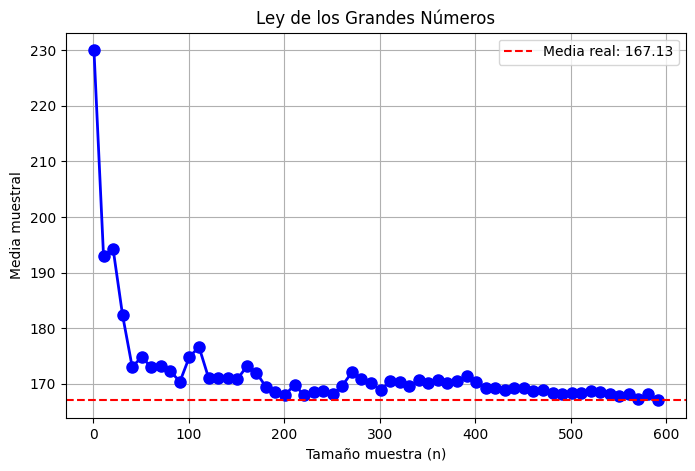

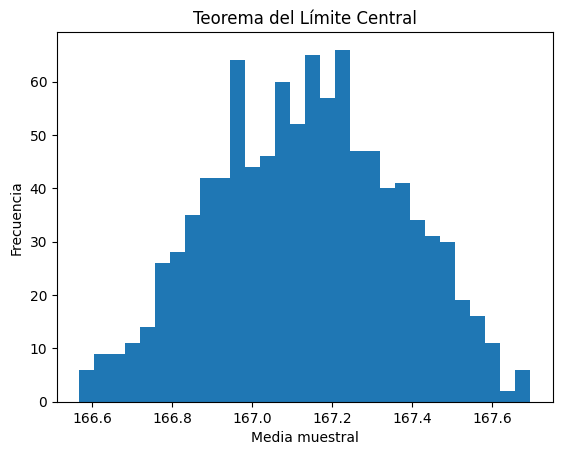

In [ ]:
#cs_estrato24 = muestreoporestrato(cs,"Variable","DViento","Unidades","deg","Tiempo de exposición (horas)",24)
condicion = "Variable == 'DViento' & Unidades == 'deg' & `Tiempo de exposición (horas)` == 24"
cs_estrato24 = muestreoporestrato(cs, condicion)
print(cs_estrato24.shape)
TLCyLGN(cs_estrato24,'Promedio',30,1000)

## Ejercicio 2


In [ ]:

def varemp (mu,sigma,n,m):
    np.random.seed(42) 
    medias=[]
    medianas=[]
    for i in range(m):
        muestra=np.random.normal(mu,sigma,n)
        medias.append(np.mean(muestra))
        medianas.append(np.median(muestra))
        
    medias=np.array(medias)
    medianas=np.array(medianas)
    return medias,medianas


### Hacerlo mil veces


In [ ]:
mu= 120
sigma =12
n=50
m=1000
medias, medianas = varemp(mu,sigma,n,m)
print(f"Varianza de medias: {np.var(medias)}")
print(f"Varianza de medianas: {np.var(medianas)}")

Varianza de medias: 2.9729837255185165
Varianza de medianas: 4.447812105867956


### Variando el tamaño de la muestra


n=10: media=125.38, mediana=126.24
n=30: media=117.74, mediana=117.19
n=50: media=117.29, mediana=117.19
n=100: media=118.75, mediana=118.48
n=300: media=119.93, mediana=120.71


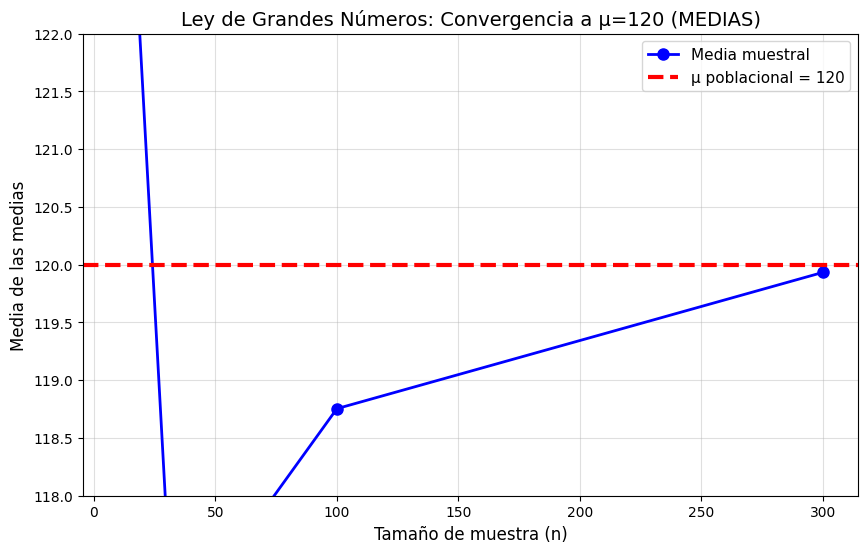

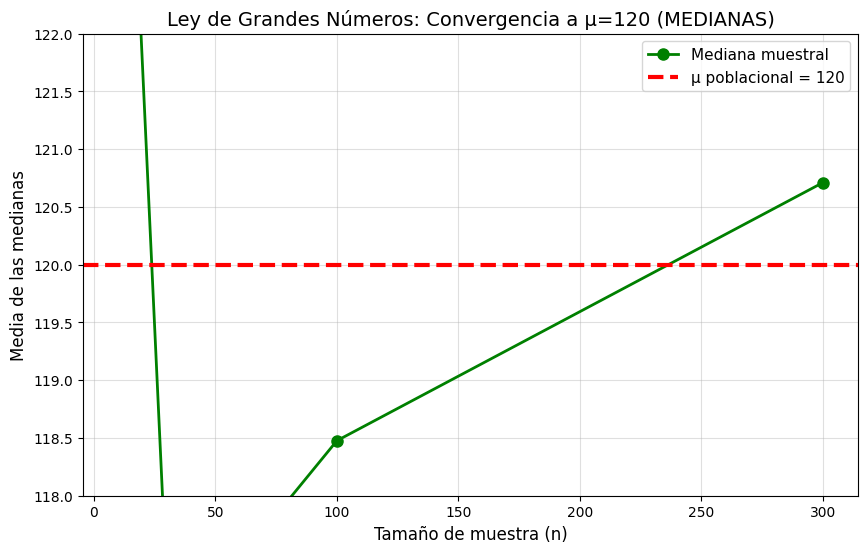

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

mu = 120  
sigma = 12
n = [10, 30, 50, 100, 300]
m = 1 


medias_promedio = []
medianas_promedio = []

for i in n:
    medias, medianas = varemp(mu, sigma, i, m)
    medias_promedio.append(np.mean(medias))
    medianas_promedio.append(np.mean(medianas))  
    print(f"n={i}: media={np.mean(medias):.2f}, mediana={np.mean(medianas):.2f}")

# ========== GRÁFICA 1: MEDIAS ==========
plt.figure(figsize=(10, 6))

plt.plot(n, medias_promedio, 'b-o', linewidth=2, markersize=8, 
        label='Media muestral')

plt.axhline(mu, color='red', linewidth=3, linestyle='--',
            label=f'μ poblacional = {mu}')

plt.xlabel('Tamaño de muestra (n)', fontsize=12)
plt.ylabel('Media de las medias', fontsize=12)
plt.title('Ley de Grandes Números: Convergencia a μ=120 (MEDIAS)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.ylim([118, 122])  
plt.show()

# ========== GRÁFICA 2: MEDIANAS ==========
plt.figure(figsize=(10, 6))

plt.plot(n, medianas_promedio, 'g-o', linewidth=2, markersize=8, 
        label='Mediana muestral')

plt.axhline(mu, color='red', linewidth=3, linestyle='--',
            label=f'μ poblacional = {mu}')

plt.xlabel('Tamaño de muestra (n)', fontsize=12)
plt.ylabel('Media de las medianas', fontsize=12)
plt.title('Ley de Grandes Números: Convergencia a μ=120 (MEDIANAS)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.ylim([118, 122])
plt.show()




# DATASET DE PROYECTO DE ESTADISTICA 2
-Juan David Gomez Mosquera 
-Miguel Ayala


In [ ]:
url= 'https://raw.githubusercontent.com/mick2332-q/Estadistica-II/main/enhanced_anxiety_dataset.csv'
cs= pd.read_csv(url)
print(cs.shape)
cs.head()

(11000, 19)


,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


In [ ]:
year_pub=2022
cs.insert(loc=1, column='Birth year', value=year_pub - cs['Age'])
cs.head()

,Age,Birth year,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,1993,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,1976,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,1958,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,2002,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,1973,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


In [ ]:
# Fórmula de conversión lineal
# DASS-21 = ((valor - 1) / (10 - 1)) × 42

cs['Stress_DASS21'] = ((cs['Stress Level (1-10)'] - 1) / 9) * 42
cs['Anxiety_DASS21'] = ((cs['Anxiety Level (1-10)'] - 1) / 9) * 42

# Verificación — tabla de equivalencias
print("Tabla de equivalencias Escala 1-10 → DASS-21:")
print("-" * 35)
for i in range(1, 11):
    dass = ((i - 1) / 9) * 42
    print(f"  Escala {i}/10  →  DASS-21: {dass:.1f}/42")

In [ ]:
# Perfil: Adultos australianos trabajadores (25-45 años al momento del estudio) con alto consumo de cafeína (>200mg/día) y poco sueño (<6hrs)
condicion = "`Birth year` >= 1977 & `Birth year` <= 1997 & `Caffeine Intake (mg/day)` > 200 & `Sleep Hours` < 6"
perfil= muestreoporestrato(cs, condicion)
perfil.describe()

print(f"Registros que cumplen el perfil: {len(perfil)}")
print(f"\nEstadísticas descriptivas del perfil:")
print(perfil[['Age', 'Caffeine Intake (mg/day)', 'Sleep Hours', 'Heart Rate (bpm)']].describe())

Registros que cumplen el perfil: 1196

Estadísticas descriptivas del perfil:
               Age  Caffeine Intake (mg/day)  Sleep Hours  Heart Rate (bpm)
count  1196.000000               1196.000000  1196.000000       1196.000000
mean     34.876254                410.000000     4.875334         99.073579
std       6.151755                108.133445     0.727501         14.627982
min      25.000000                201.000000     2.300000         60.000000
25%      29.750000                319.000000     4.400000         92.000000
50%      35.000000                401.000000     4.900000        102.000000
75%      40.000000                505.000000     5.500000        111.000000
max      45.000000                599.000000     5.900000        119.000000


In [ ]:
variable = 'Heart Rate (bpm)'

# Si el subgrupo tiene menos de 200 ajusta el tamaño de la muestra al número de registros disponibles
n_muestra = min(200, len(perfil[variable].dropna()))

np.random.seed(42)
muestra = perfil[variable].dropna().sample(n=n_muestra, random_state=42).values

print(f"Variable analizada: {variable}")
print(f"Tamaño de la muestra: {len(muestra)}")
print(f"Primeros 10 valores: {muestra[:10]}")# para ver si se hizo el muestreo correctamente con la semilla fija

Variable analizada: Heart Rate (bpm)
Tamaño de la muestra: 200
Primeros 10 valores: [108  90 108  68  82  93  91  80  93 100]


In [ ]:
n = len(muestra)
media = np.mean(muestra)
varianza = np.var(muestra, ddof=1)    # S² muestral
desv_std = np.std(muestra, ddof=1)    # S muestral


print(f"  ESTADÍSTICAS DE LA MUESTRA")
print("=" * 45)
print(f"  n                    : {n}")
print(f"  Media muestral (x̄)  : {media:.4f} bpm")
print(f"  Varianza muestral(S²): {varianza:.4f}")
print(f"  Desviación std (S)   : {desv_std:.4f}")


  ESTADÍSTICAS DE LA MUESTRA
  n                    : 200
  Media muestral (x̄)  : 98.6350 bpm
  Varianza muestral(S²): 199.0370
  Desviación std (S)   : 14.1080


In [ ]:
# α = 0.05 → confianza del 95%
# gl = n - 1 = 199
alpha = 0.05
gl = n - 1

# Valor crítico t bilateral (α/2 en cada cola)
t_critico = stat.t.ppf(1 - alpha/2, df=gl)

# Margen de error
margen = t_critico * (desv_std / np.sqrt(n))

IC_media_inf = media - margen
IC_media_sup = media + margen


print(f"  INTERVALO DE CONFIANZA PARA LA MEDIA")
print(f"  t crítico (gl=199, α/2): {t_critico:.4f}")
print(f"  Margen de error        : ± {margen:.4f}")
print(f"  IC 95%: [ {IC_media_inf:.4f} , {IC_media_sup:.4f} ]")


  INTERVALO DE CONFIANZA PARA LA MEDIA
  t crítico (gl=199, α/2): 1.9720
  Margen de error        : ± 1.9672
  IC 95%: [ 96.6678 , 100.6022 ]


In [ ]:
# Fórmula:
#   LI = (n-1)*S² / χ²(1-α/2)
#   LS = (n-1)*S² / χ²(α/2)

chi2_izq = stat.chi2.ppf(alpha/2, df=gl)
chi2_der = stat.chi2.ppf(1 - alpha/2, df=gl)

IC_var_inf = (gl * varianza) / chi2_der
IC_var_sup = (gl * varianza) / chi2_izq


print(f"  INTERVALO DE CONFIANZA PARA LA VARIANZA")
print(f"  χ² izquierdo (α/2)   : {chi2_izq:.4f}")
print(f"  χ² derecho (1-α/2)   : {chi2_der:.4f}")
print(f"  IC 95%: [ {IC_var_inf:.4f} , {IC_var_sup:.4f} ]")


  INTERVALO DE CONFIANZA PARA LA VARIANZA
  χ² izquierdo (α/2)   : 161.8262
  χ² derecho (1-α/2)   : 239.9597
  IC 95%: [ 165.0625 , 244.7586 ]


In [ ]:
# Fuente: Heart Foundation Australia / AIHW
# Frecuencia cardíaca en reposo promedio adultos australianos: 72 bpm
# https://www.heartfoundation.org.au/

media_referencia = 72.0


print(f"COMPARACIÓN CON REFERENCIA EXTERNA")

print(f"Fuente: Heart Foundation Australia")
print(f"Media poblacional de referencia : {media_referencia} bpm")
print(f"Media de nuestra muestra (x̄)   : {media:.4f} bpm")
print(f"IC 95% obtenido: [{IC_media_inf:.4f} , {IC_media_sup:.4f}]")


if IC_media_inf <= media_referencia <= IC_media_sup:
    print(f"{media_referencia} bpm SÍ está dentro del intervalo.")
    print(f"No hay evidencia estadística de que este perfil")
    print(f"tenga una FC diferente a la media australiana.")
else:
    print(f"{media_referencia} bpm NO está dentro del intervalo.")
    if media > media_referencia:
        print(f"El perfil (cafeína alta + poco sueño) muestra una FC significativamente MAYOR a la media")
    else:
        print(f"La FC de este perfil es significativamenteMENOR a la media australiana.")


COMPARACIÓN CON REFERENCIA EXTERNA
Fuente: Heart Foundation Australia
Media poblacional de referencia : 72.0 bpm
Media de nuestra muestra (x̄)   : 98.6350 bpm
IC 95% obtenido: [96.6678 , 100.6022]
72.0 bpm NO está dentro del intervalo.
El perfil (cafeína alta + poco sueño) muestra una FC significativamente MAYOR a la media


In [ ]:
x=(98-100)/(2/np.sqrt(9))
print(x)

-3.0


## Función completa

In [ ]:
print(stat.norm.ppf(0.95))

1.6448536269514722


In [ ]:
def prueba_hipotesis_completa(x_barra, mu_0, sigma, n, alpha, cola, x_sup):
    z = (x_barra - mu_0) / (sigma / np.sqrt(n))
    delta = abs(x_sup - mu_0) / (sigma / np.sqrt(n))
    x = np.linspace(-5, 5, 1000)
    y_H0 = stat.norm.pdf(x, 0, 1)
    y_H1 = stat.norm.pdf(x, delta, 1)
    plt.figure(figsize=(10,6))
    
    plt.plot(x, y_H0, label='Distribución bajo H0')
    plt.plot(x, y_H1, linestyle='--', label='Distribución bajo H1')
    match cola:
        case 'inf':  # H₁: μ < μ₀  
            z_alpha = stat.norm.ppf(1 - alpha)   
            z_crit = -z_alpha                   
            decision = z < z_crit
            p_value = stat.norm.cdf(z) 
            beta = stat.norm.cdf(z_alpha + delta)
            limite_sup = x_barra + z_alpha * (sigma / np.sqrt(n))
            IC = (-np.inf, limite_sup)
            plt.fill_between(x, y_H0, where=(x < z_crit), alpha=0.3)
            plt.fill_between(x, y_H1, where=(x >= z_crit), alpha=0.3)
            
        case 'sup':  # H₁: μ > μ₀  
            z_alpha = stat.norm.ppf(1 - alpha)    
            z_crit = +z_alpha                  
            decision = z > z_crit
            p_value = 1-stat.norm.cdf(z)
            beta = stat.norm.cdf(z_alpha - delta)
            limite_inf = x_barra - z_alpha * (sigma / np.sqrt(n))
            IC = (limite_inf, np.inf)
            plt.fill_between(x, y_H0, where=(x > z_crit), alpha=0.3)
            plt.fill_between(x, y_H1, where=(x <= z_crit), alpha=0.3)
            
        case 'dos':  # H₁: μ ≠ μ₀
            z_alpha = stat.norm.ppf(1 - alpha/2)  
            z_crit = z_alpha                    
            decision = abs(z) > z_crit
            p_value = 2 * (1 - stat.norm.cdf(abs(z)))
            beta = stat.norm.cdf(z_alpha - delta)-stat.norm.cdf(-z_alpha - delta)
            limite_inf = x_barra - z_alpha * (sigma / np.sqrt(n))
            limite_sup = x_barra + z_alpha * (sigma / np.sqrt(n))
            IC = (limite_inf, limite_sup)
            plt.fill_between(x, y_H0, where=(x > z_crit), alpha=0.3)
            plt.fill_between(x, y_H0, where=(x < -z_crit), alpha=0.3)
            plt.fill_between(x, y_H1, where=(abs(x) <= z_crit), alpha=0.3)
            
        case _:
            raise ValueError("cola no válida")
        
    plt.axvline(z, linestyle=':', label='Z observado')
    plt.title("Prueba de hipótesis completa")
    plt.legend()
    plt.grid()
    plt.show()
    
    
    return {
        'z': z,
        'decision': decision,
        'p_value': p_value,
        'beta': beta,
        'IC': IC
    }




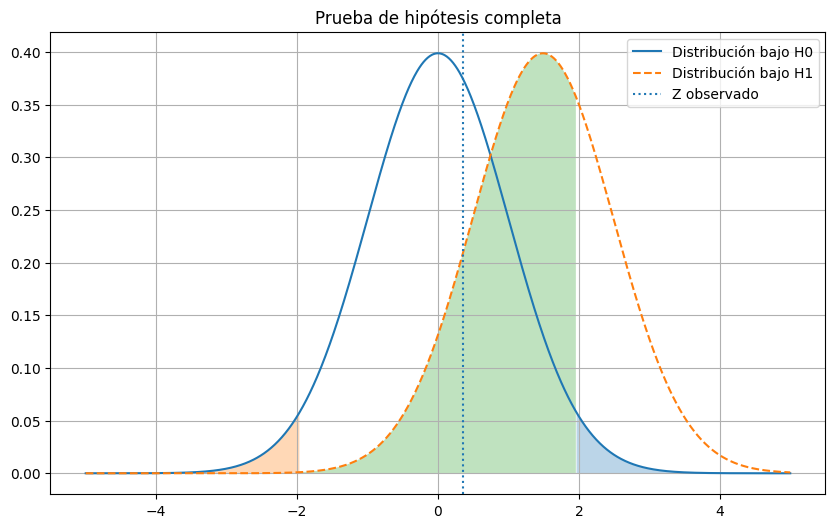

0.3577708763999693
False
0.7205147871362532
0.6802756473119772
(np.float64(87.85043237827026), np.float64(93.10956762172975))


In [ ]:
respuesta=prueba_hipotesis_completa(90.48,90,3,5,0.05,'dos',92)
print(f'{respuesta['z']}')
print(f'{respuesta["decision"]}')
print(f'{respuesta["p_value"]}')
print(f'{respuesta["beta"]}')
print(f'{respuesta["IC"]}')